# Chapter 15. 잠재변수 생성모델: VAE — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml2/chapter09_vae_elbo.ipynb)

책 본문: [Chapter 15](https://smhanlab.com/book-ml/kor/ml1/chapter15.html)

VAE 손실(ELBO의 음수)의 두 항 — 복원 항과 KL 정규화 항 — 을 직접
계산해보고, KL 항이 왜 잠재공간을 표준정규분포 쪽으로 끌어당기는지
그래프로 확인합니다.

## 1. KL divergence 항 (책 9.4절, 연습문제 검증 예제 그대로)

In [1]:
import math

def kl_divergence_gaussian(mu, log_var):
    # D_KL( N(mu, sigma^2) || N(0,1) ) = -1/2 * (1 + log(sigma^2) - mu^2 - sigma^2)
    return -0.5 * (1 + log_var - mu ** 2 - math.exp(log_var))

print(kl_divergence_gaussian(mu=0.0, log_var=0.0))  # 0.0  (표준정규분포와 완전히 같음)
print(kl_divergence_gaussian(mu=2.0, log_var=0.0))  # 2.0  (평균이 멀어질수록 커짐)
assert abs(kl_divergence_gaussian(0.0, 0.0) - 0.0) < 1e-9
assert abs(kl_divergence_gaussian(2.0, 0.0) - 2.0) < 1e-9
print("책의 두 예시와 정확히 일치.")

-0.0
2.0
책의 두 예시와 정확히 일치.


## 2. 전체 VAE 손실 = 복원 손실 + KL 항들의 합

In [2]:
def vae_loss(recon_loss, mu_list, log_var_list):
    kl_total = sum(kl_divergence_gaussian(mu, lv) for mu, lv in zip(mu_list, log_var_list))
    return recon_loss + kl_total

loss = vae_loss(recon_loss=5.0, mu_list=[0.5, -0.3], log_var_list=[0.1, -0.2])
print(f"vae_loss = {loss:.4f}")

vae_loss = 5.1820


## 3. 왜 KL 항이 "잠재공간을 매끄럽게" 만드는가

\\(\mu\\)가 0에서 멀어질수록 KL 페널티가 어떻게 커지는지 그래프로
봅니다 — 인코더가 아무 데나 점을 흩어놓으면 이 항이 손실을 키워서
막아준다는 뜻입니다.

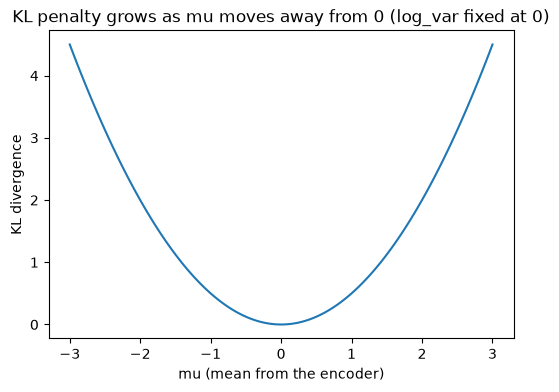

In [3]:
import matplotlib.pyplot as plt

mus = [-3 + 0.05 * i for i in range(121)]  # -3 ~ 3
kl_at_logvar0 = [kl_divergence_gaussian(m, 0.0) for m in mus]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mus, kl_at_logvar0)
ax.set_xlabel("mu (mean from the encoder)")
ax.set_ylabel("KL divergence")
ax.set_title("KL penalty grows as mu moves away from 0 (log_var fixed at 0)")
plt.show()